# Project 4: coupled-cluster doubles for quantum dots, three ways

Companion notebook to Appendix A, Project 4, of *Quantum mechanics for
many-particle systems*.  The code is the same as in
`BookManybody/BookPrograms/appendixA/ccdchannels.py`, which builds on
`quantumdot.py` of chapter 11 (the oscillator basis and the Coulomb matrix
elements) and on `coupledcluster.py` of chapter 10 (the dense
coupled-cluster solver); the notebook runs it section by section.

The system is the two-dimensional quantum dot of chapter 11,

$$
\hat H=\sum_{i=1}^N\Big(-\tfrac12\nabla_i^2+\tfrac12\omega^2r_i^2\Big)
+\sum_{i<j}^N\frac{1}{r_{ij}},
$$

for the closed shells $N=2,6,12$ and $20$, and the task of the project is
to *write a CCD code* -- first as the equations stand, then as
matrix-matrix multiplications in channels of conserved quantum numbers --
and to benchmark it: against the dense solver of chapter 10, against the
two-electron full CI of chapter 5, and against the random-phase
approximation of chapter 7, which turns out to be a piece of CCD.

In [1]:
import sys, os, glob, time
import numpy as np
import matplotlib.pyplot as plt

for _pattern in ("chapter*", "appendix*"):
    for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                            "BookPrograms", _pattern))):
        if _d not in sys.path:
            sys.path.insert(0, _d)
import ccdchannels as cc
from quantumdot import QuantumDot, matrices
from coupledcluster import ccd as ccd_dense, reference_energy, mp2_energy

np.set_printoptions(precision=6, suppress=True, linewidth=120)

## 1. The basis, the magic numbers and the Hartree-Fock reference

The single-particle states are the two-dimensional oscillator functions
labelled by $(n,m,m_s)$ with energy $\varepsilon=\omega(2n+|m|+1)$; the
shell $N_s=2n+|m|$ holds $2(N_s+1)$ electrons, and the closed shells are
$N=2,6,12,20,30,\ldots$  `quantumdot.py` supplies the antisymmetrised
Coulomb elements $\langle pq|\hat v|rs\rangle_{\rm AS}$, which vanish
unless $m_p+m_q=m_r+m_s$ and $m_{s_p}+m_{s_q}=m_{s_r}+m_{s_s}$.

The Hartree-Fock equations of chapter 6 are solved with the Fock matrix
diagonalised block by block in $(m,m_s)$, so that every orbital keeps
its quantum numbers; the reference energy
$E_{\rm ref}=\sum_i\langle i|\hat h|i\rangle+\frac12\sum_{ij}\langle ij|\hat v|ij\rangle_{\rm AS}$
evaluated with the transformed matrix elements must reproduce the
Hartree-Fock energy, and the occupied-virtual block of the Fock matrix
must vanish (Brillouin's theorem).  That is the first test of a
transformed set of matrix elements, and every CCD code should pass it
before anything else is tried.

In [2]:
dot = QuantumDot(2, shells=5)
print("magic numbers:", dot.magic_numbers())
for N in (2, 6, 12, 20):
    dot = QuantumDot(N, shells=5)
    h, v = matrices(5)
    h_hf, v_hf, eps, labels, C, it = cc.hartree_fock_blocks(dot, h, v, N)
    f = np.diag(eps)
    F = h_hf + np.einsum("piqi->pq", v_hf[:, :N, :, :N])
    print(f"N = {N:2d}: E_0 = {np.sum(dot.energies()[:N]):8.4f}, E_ref(osc.) = {reference_energy(h, v, N):12.8f}, "
          f"E_HF = {reference_energy(h_hf, v_hf, N):12.8f} ({it} iterations), "
          f"max |f_ai| = {np.abs(F[N:, :N]).max():.1e}, max |f_pq - eps| = {np.abs(F - f).max():.1e}")

magic numbers: [2, 6, 12, 20, 30, 42]


N =  2: E_0 =   2.0000, E_ref(osc.) =   3.25331414, E_HF =   3.16192140 (15 iterations), max |f_ai| = 1.2e-15, max |f_pq - eps| = 4.4e-15
N =  6: E_0 =  10.0000, E_ref(osc.) =  22.21981284, E_HF =  20.72025707 (24 iterations), max |f_ai| = 2.4e-15, max |f_pq - eps| = 1.4e-14


N = 12: E_0 =  28.0000, E_ref(osc.) =  73.76554905, E_HF =  67.29686927 (30 iterations), max |f_ai| = 3.8e-15, max |f_pq - eps| = 2.0e-14
N = 20: E_0 =  60.0000, E_ref(osc.) = 177.96329742, E_HF = 161.33972067 (25 iterations), max |f_ai| = 4.9e-15, max |f_pq - eps| = 1.6e-14


## 2. The CCD equations as they stand

With $\hat T\approx\hat T_2=\frac14\sum t_{ij}^{ab}a^\dagger_aa^\dagger_ba_ja_i$
the energy is $E_{\rm CCD}=E_{\rm ref}+\frac14\sum_{ijab}\langle ij|\hat v|ab\rangle t_{ij}^{ab}$
and the amplitudes solve, for all $i>j$, $a>b$,

$$
\begin{aligned}
0={}&\langle ab|\hat v|ij\rangle+(\varepsilon_a+\varepsilon_b-\varepsilon_i-\varepsilon_j)t_{ij}^{ab}
+\tfrac12\sum_{cd}\langle ab|\hat v|cd\rangle t_{ij}^{cd}
+\tfrac12\sum_{kl}\langle kl|\hat v|ij\rangle t_{kl}^{ab}
+\hat P(ij|ab)\sum_{kc}\langle kb|\hat v|cj\rangle t_{ik}^{ac}\\
&+\tfrac14\sum_{klcd}\langle kl|\hat v|cd\rangle t_{ij}^{cd}t_{kl}^{ab}
+\hat P(ij)\sum_{klcd}\langle kl|\hat v|cd\rangle t_{ik}^{ac}t_{jl}^{bd}
-\tfrac12\hat P(ij)\sum_{klcd}\langle kl|\hat v|cd\rangle t_{ik}^{dc}t_{lj}^{ab}
-\tfrac12\hat P(ab)\sum_{klcd}\langle kl|\hat v|cd\rangle t_{lk}^{ac}t_{ij}^{db},
\end{aligned}
$$

with antisymmetrised matrix elements throughout.  The function
`ccd_naive` encodes this literally, one Python loop per index, and
iterates $t\leftarrow-(\text{everything else})/(\varepsilon_a+\varepsilon_b-\varepsilon_i-\varepsilon_j)$
from the MP2 guess.  It is correct, and it is hopeless: the quadratic
terms cost $n_h^4n_p^4$ operations per iteration.

In [3]:
for shells in (1, 2):
    dot = QuantumDot(2, shells)
    h, v = matrices(shells)
    h_hf, v_hf, eps, labels, C, it = cc.hartree_fock_blocks(dot, h, v, 2)
    f = np.diag(eps)
    t0 = time.time(); naive = cc.ccd_naive(eps, v_hf, 2); t_naive = time.time() - t0
    t0 = time.time(); dense = ccd_dense(f, v_hf, 2); t_dense = time.time() - t0
    exact = cc.two_electron_spectrum(h, v)[0]
    E_hf = reference_energy(h_hf, v_hf, 2)
    print(f"shells 0-{shells}, {h.shape[0]} spin-orbitals: E_HF = {E_hf:.8f}")
    print(f"   naive loops : E_corr = {naive['energy']:.12f}   {t_naive:7.2f} s for {naive['iterations']} iterations")
    print(f"   dense einsum: E_corr = {dense['energy']:.12f}   {t_dense:7.3f} s")
    print(f"   two-electron FCI: {exact:.8f};  E_HF + E_CCD = {E_hf + naive['energy']:.8f}")

shells 0-1, 6 spin-orbitals: E_HF = 3.25331414
   naive loops : E_corr = -0.100986130200      0.26 s for 14 iterations
   dense einsum: E_corr = -0.100986130218     0.002 s
   two-electron FCI: 3.15232801;  E_HF + E_CCD = 3.15232801


shells 0-2, 12 spin-orbitals: E_HF = 3.16269135
   naive loops : E_corr = -0.123643528496      6.31 s for 18 iterations
   dense einsum: E_corr = -0.123643528517     0.010 s
   two-electron FCI: 3.03860458;  E_HF + E_CCD = 3.03904782


For six spin-orbitals CCD *is* exact for two electrons: there are no
triples or quadruples, and the singles are absent only because the CCD
amplitudes happen to make them so in this tiny space.  Already for twelve
orbitals CCD misses the FCI energy by $4\times10^{-4}$, the singles
contribution discussed in chapter 11.

## 3. Channels

A two-particle configuration $(p,q)$ carries the conserved quantum numbers
$M=m_p+m_q$ and $S=m_{s_p}+m_{s_q}$, and the interaction cannot change
them.  Sorting the pairs $a<b$ and $i<j$ by $(M,S)$ turns every matrix in
the ladder terms into a block-diagonal one, and the contractions into small
matrix products:

$$
\sum_{c<d}\langle ab|\hat v|cd\rangle t_{ij}^{cd}\to \mathbf V_{pp}^{(M,S)}\mathbf T^{(M,S)},\qquad
\sum_{k<l}t_{kl}^{ab}\langle kl|\hat v|ij\rangle\to \mathbf T^{(M,S)}\mathbf V_{hh}^{(M,S)},\qquad
\tfrac14\sum_{klcd}\to \mathbf T^{(M,S)}\big(\mathbf V_{hhpp}^{(M,S)}\mathbf T^{(M,S)}\big).
$$

The ring terms couple a particle to a hole instead.  Re-sorting the
amplitudes as $\tilde t_{(ai),(ck)}=t_{ik}^{ac}$, a particle-hole pair
$(a,i)$ carries $(m_a-m_i,\,m_{s_a}-m_{s_i})$, and

$$
\sum_{kc}t_{ik}^{ac}\langle kb|\hat v|cj\rangle\to\tilde{\mathbf T}\,\mathbf W,\qquad
\sum_{klcd}\langle kl|\hat v|cd\rangle t_{ik}^{ac}t_{jl}^{bd}\to
\tilde{\mathbf T}\,\mathbf X\,\tilde{\mathbf T}^{\rm T},
$$

again block by block.  The two remaining quadratic terms are products with
the one-body intermediates $F_{li}=\frac12\sum_{kcd}\langle kl|\hat v|cd\rangle t_{ik}^{cd}$
and $G_{ad}=\frac12\sum_{klc}\langle kl|\hat v|cd\rangle t_{kl}^{ac}$ -- the
$F_{mi}$ and $F_{ae}$ of the Stanton-Gauss-Watts-Bartlett intermediates in
chapter 10.  The class `ChannelCCD` does exactly this, and agrees with the
dense solver of chapter 10 to machine precision.

In [4]:
results = {}
print(f"{'N':>3s} {'norb':>5s} {'E_HF':>13s} {'E_MP2':>12s} {'E_CCD':>12s} {'|dense - channels|':>18s} "
      f"{'t_channels':>10s} {'t_dense':>8s} {'channels':>9s} {'largest block':>14s}")
for N in (2, 6, 12, 20):
    r = cc.run(N, shells=5)
    results[N] = r
    sizes = sorted(r["channels"].block_sizes.values(), key=lambda s: s[0] * s[1], reverse=True)
    print(f"{N:3d} {r['n_orbitals']:5d} {r['E_HF']:13.8f} {r['E_MP2']:12.8f} {r['E_CCD']:12.8f} "
          f"{abs(r['E_CCD'] - r['E_CCD_dense']):18.1e} {r['t_channels']:10.2f} {r['t_dense']:8.2f} "
          f"{len(sizes):9d} {str(sizes[0]):>14s}")

  N  norb          E_HF        E_MP2        E_CCD |dense - channels| t_channels  t_dense  channels  largest block


  2    42    3.16192140  -0.13488329  -0.14799908            5.6e-17       0.04     1.56         1        (42, 1)


  6    42   20.72025707  -0.41769581  -0.44624450            0.0e+00       0.13     5.41        11        (32, 3)


 12    42   67.29686927  -0.74795401  -0.77019290            0.0e+00       0.40    13.63        23        (23, 8)


 20    42  161.33972067  -0.79449291  -0.74521361            1.1e-16       0.46    12.62        35       (11, 16)


The channel code is faster by a large factor because it never touches the
zeros: with $42$ spin-orbitals the dense $\langle pq|\hat v|rs\rangle_{\rm AS}$
has $42^4\approx3\times10^6$ entries of which only a few per cent are
non-zero, and the pair blocks are at most a few tens of rows.  The price
is bookkeeping, and the reward, beyond speed, is that the ladder and ring
structure of the equations is now visible in the code.

### Cost against basis size

shells 0-3, N =  2:  20 orbitals, E_HF + E_CCD =   3.02527309, channels   0.02 s (22 it.), dense   0.11 s


shells 0-3, N =  6:  20 orbitals, E_HF + E_CCD =  20.42926433, channels   0.07 s (23 it.), dense   0.25 s


shells 0-3, N = 12:  20 orbitals, E_HF + E_CCD =  70.32424919, channels   0.13 s (34 it.), dense   0.37 s


shells 0-4, N =  2:  30 orbitals, E_HF + E_CCD =   3.01794371, channels   0.04 s (23 it.), dense   0.45 s


shells 0-4, N =  6:  30 orbitals, E_HF + E_CCD =  20.33245307, channels   0.09 s (24 it.), dense   1.46 s


...

shells 0-5, N = 20:  42 orbitals, E_HF + E_CCD = 160.59450705, channels   0.43 s (22 it.), dense  12.26 s


shells 0-6, N =  2:  56 orbitals, E_HF + E_CCD =   3.01140528, channels   0.09 s (23 it.), dense   4.85 s


shells 0-6, N =  6:  56 orbitals, E_HF + E_CCD =  20.24984786, channels   0.33 s (26 it.), dense  22.78 s


shells 0-6, N = 12:  56 orbitals, E_HF + E_CCD =  66.04956381, channels   0.81 s (29 it.), dense  56.47 s


shells 0-6, N = 20:  56 orbitals, E_HF + E_CCD = 158.84111858, channels   1.79 s (35 it.), dense 105.22 s


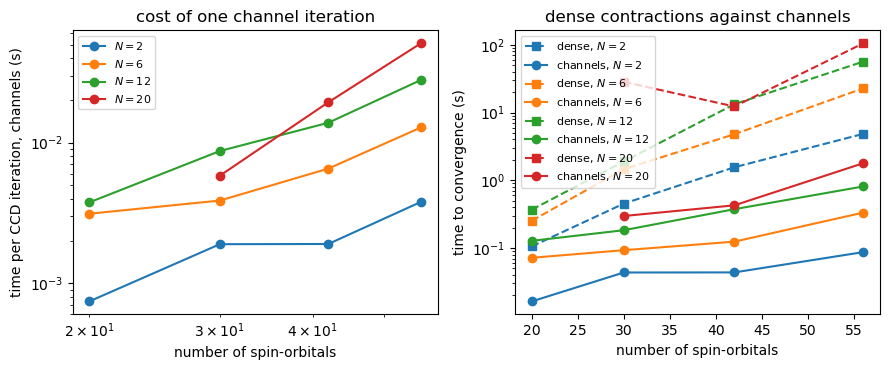

In [5]:
timings = {N: [] for N in (2, 6, 12, 20)}
for shells in (3, 4, 5, 6):
    for N in (2, 6, 12, 20):
        if N >= QuantumDot(N, shells).n_orbitals:      # no empty orbitals: nothing to correlate
            continue
        r = cc.run(N, shells)
        timings[N].append((r["n_orbitals"], r["t_channels"] / r["ccd_iterations"],
                           r["t_dense"], r["E_HF"] + r["E_CCD"], r["E_MP2"], r["E_rCCD"], r["E_RPA"], r["rpa_imag"],
                           r["t_channels"]))
        print(f"shells 0-{shells}, N = {N:2d}: {r['n_orbitals']:3d} orbitals, "
              f"E_HF + E_CCD = {r['E_HF'] + r['E_CCD']:12.8f}, "
              f"channels {r['t_channels']:6.2f} s ({r['ccd_iterations']} it.), dense {r['t_dense']:6.2f} s")

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.8))
for N, rows in timings.items():
    rows = np.array(rows)
    axes[0].loglog(rows[:, 0], rows[:, 1], "o-", label=f"$N={N}$")
axes[0].set_xlabel("number of spin-orbitals")
axes[0].set_ylabel("time per CCD iteration, channels (s)")
axes[0].set_title("cost of one channel iteration")
axes[0].legend(fontsize=8)
for N, rows in timings.items():
    rows = np.array(rows)
    axes[1].semilogy(rows[:, 0], rows[:, 2], "s--", color=f"C{[2, 6, 12, 20].index(N)}", label=f"dense, $N={N}$")
    axes[1].semilogy(rows[:, 0], rows[:, 8], "o-", color=f"C{[2, 6, 12, 20].index(N)}", label=f"channels, $N={N}$")
axes[1].set_xlabel("number of spin-orbitals")
axes[1].set_ylabel("time to convergence (s)")
axes[1].set_title("dense contractions against channels")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Convergence with the basis and the reference values

For two electrons at $\omega=1$ the exact energy is Taut's $E=3$
(chapter 11), and the full CI in each basis is the exact answer *in that
basis*; for $N=6$, $12$ and $20$ the reference values are the diffusion
Monte Carlo energies of Pedersen *et al.*, $20.1597(2)$, $65.700(1)$
and $155.868(1)$.  We follow $E_{\rm HF}+E_{\rm CCD}$ as the basis grows.

In [6]:
reference = {2: 3.0, 6: 20.1597, 12: 65.700, 20: 155.868}
conv = {N: [] for N in (2, 6, 12, 20)}
for shells in (3, 4, 5, 6, 7):
    h, v = matrices(shells)
    for N in (2, 6, 12, 20):
        if N >= h.shape[0]:
            continue
        r = cc.run(N, shells, dense=False)
        fci = cc.two_electron_spectrum(h, v)[0] if N == 2 else np.nan
        conv[N].append((shells, r["n_orbitals"], r["E_HF"], r["E_HF"] + r["E_MP2"], r["E_HF"] + r["E_CCD"], fci))
    print(f"shells 0-{shells} done ({h.shape[0]} orbitals)")

fig, axes = plt.subplots(2, 2, figsize=(9.0, 6.4))
for ax, N in zip(axes.flat, (2, 6, 12, 20)):
    rows = np.array(conv[N])
    ax.plot(rows[:, 1], rows[:, 2], "s-", label=r"$E_{\rm HF}$")
    ax.plot(rows[:, 1], rows[:, 3], "^-", label=r"$E_{\rm HF}+E_{\rm MP2}$")
    ax.plot(rows[:, 1], rows[:, 4], "o-", label=r"$E_{\rm HF}+E_{\rm CCD}$")
    if N == 2:
        ax.plot(rows[:, 1], rows[:, 5], "d--", label="full CI")
    ax.axhline(reference[N], color="k", lw=0.8, ls=":", label="reference")
    ax.set_xlabel("number of spin-orbitals")
    ax.set_ylabel("energy (a.u.)")
    ax.set_title(f"$N={N}$, $\\omega=1$")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()
for N in (2, 6, 12, 20):
    rows = conv[N]
    print(f"N = {N:2d}: " + ", ".join(f"{int(s)} shells: {e:.5f}" for s, n, ehf, emp2, e, fci in rows)
          + f"   (reference {reference[N]})")

shells 0-3 done (20 orbitals)


KeyboardInterrupt: 

The convergence in the number of oscillator shells is slow, as it must be
for a Coulomb cusp expanded in smooth functions (chapter 11 discusses the
$1/N_s$ tail), and CCD in a finite basis approaches its own complete-basis
limit, not the exact energy: the singles and the triples are missing.  For
$N=2$ the difference between CCD and full CI in the same basis is that of
the singles alone.

## 5. Rings, ladders and the random-phase approximation

Chapter 7 ended with the remark that the RPA ground state is an
exponential of two-body operators, $|{\rm RPA}\rangle\propto
\exp\{\frac12\sum Z_{mi,nj}a^\dagger_ma_ia^\dagger_na_j\}|{\rm HF}\rangle$
with $\mathbf Z=\mathbf Y^*(\mathbf X^*)^{-1}$ -- a doubles theory in
disguise.  Here is the precise statement.  Keep in the CCD equations only
the driver, the linear ring and the quadratic ring, and write the
amplitudes as a matrix over particle-hole pairs, $T_{(ai),(bj)}=t_{ij}^{ab}$.
The equations become the Riccati equation

$$
\mathbf B+\mathbf A\mathbf T+\mathbf T\mathbf A+\mathbf T\mathbf B\mathbf T=0,
$$

with the $\mathbf A$ and $\mathbf B$ of chapter 7, and the energy
$E=\frac12{\rm Tr}(\mathbf B\mathbf T)$.  If $(\mathbf X,\mathbf Y)$ are the
positive-frequency RPA eigenvectors, $\mathbf T=\mathbf Y\mathbf X^{-1}$
solves the Riccati equation and
$\frac12{\rm Tr}(\mathbf B\mathbf T)=\frac12\big(\sum_\nu\omega_\nu-{\rm Tr}\mathbf A\big)$,
the RPA correlation energy of chapter 7 (Scuseria, Henderson and Sorensen,
2008).  `ring_ccd` iterates the Riccati equation exactly as the CCD
equations are iterated and reproduces the RPA result from the
eigenvalues.

In [ ]:
print(f"{'N':>3s} {'E_MP2':>12s} {'E_CCD':>12s} {'E_ring-CCD':>12s} {'E_RPA':>12s} {'Riccati':>9s} "
      f"{'min eig(A-B)':>13s} {'imag.':>6s}")
for N in (2, 6, 12, 20):
    r = results[N]
    print(f"{N:3d} {r['E_MP2']:12.8f} {r['E_CCD']:12.8f} {r['E_rCCD']:12.8f} {r['E_RPA']:12.8f} "
          f"{r['riccati']:9.1e} {r['stability'][0]:13.4f} {r['rpa_imag']:6d}")
r = results[2]
print()
print("two electrons: lowest TDA roots", np.round(r["omega_tda"], 4))
print("               lowest RPA roots", np.round(r["omega_rpa"], 4))
print("               exact excitations", np.round(r["exact"][1:] - r["exact"][0], 4))

The identity holds to the precision of the iterations -- ring-CCD and the
RPA are the same theory -- but the number it produces is wrong by a factor
of four.  The RPA correlation energy of these dots is far too negative,
and the lowest RPA excitation lies far below the exact one.  The reason is
in the last column: the smallest eigenvalue of $\mathbf A-\mathbf B$ is
small, the Hartree-Fock determinant is close to a triplet instability in
the sense of chapter 7, and the RPA amplifies the soft particle-hole
modes without the ladder terms that hold them in check.  In the electron
gas of chapter 6 the rings are the whole story at high density; in a
finite dot with a few electrons the ladders -- the $pp$ and $hh$ channels
of the code above -- carry most of the correlation, and it is the full
CCD, rings and ladders together, that lands within a per cent of the
exact answer.  Comparing the three columns is the most direct way to see
which diagrams matter for a given system.

### Dependence on the confinement

In [ ]:
omegas = (0.1, 0.25, 0.5, 1.0, 2.0)
scan = {N: [] for N in (2, 6)}
for N in (2, 6):
    for hw in omegas:
        r = cc.run(N, 5, hw=hw, dense=False)
        scan[N].append((hw, r["E_HF"], r["E_MP2"], r["E_CCD"], r["E_RPA"], r["rpa_imag"], r["stability"][0]))
        print(f"N = {N}, omega = {hw:5.2f}: E_HF = {r['E_HF']:11.6f}, E_MP2 = {r['E_MP2']:10.6f}, "
              f"E_CCD = {r['E_CCD']:10.6f}, E_RPA = {r['E_RPA']:10.6f}, "
              f"min eig(A-B) = {r['stability'][0]:8.4f}, imaginary roots {r['rpa_imag']}")

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.8))
for ax, N in zip(axes, (2, 6)):
    rows = np.array(scan[N])
    ax.semilogx(rows[:, 0], rows[:, 2], "^-", label=r"$E_{\rm MP2}$")
    ax.semilogx(rows[:, 0], rows[:, 3], "o-", label=r"$E_{\rm CCD}$")
    ax.semilogx(rows[:, 0], rows[:, 4], "s-", label=r"$E_{\rm RPA}=E_{\rm ring\,CCD}$")
    unstable = rows[rows[:, 5] > 0, 0]
    if len(unstable):
        ax.axvspan(0.8 * unstable.min(), 1.25 * unstable.max(), color="0.85",
                   label="RPA unstable: imaginary roots")
    ax.set_xlabel(r"$\omega$")
    ax.set_ylabel("correlation energy (a.u.)")
    ax.set_title(f"$N={N}$: MP2, CCD and RPA against the confinement")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

As the trap is opened the electrons have more room to avoid one another,
correlation grows relative to the mean field, and the RPA moves towards
an instability: the smallest eigenvalue of $\mathbf A-\mathbf B$ shrinks
and the ring series eventually diverges.  CCD, with the ladders, stays
finite -- which is the practical reason coupled cluster rather than the
RPA is the workhorse for finite systems.

## Summary

Three codes, one energy.  The naive code proves the equations; the dense
code of chapter 10 is what one writes first; the channel code is what one
writes when the basis grows, and it exposes the diagrammatic content of
CCD -- ladders in the pair channels, rings in the cross channels -- so
clearly that the RPA drops out as the special case of rings alone.